<a href="https://colab.research.google.com/github/awesomebruh03/DCCTN/blob/main/DCCTN_V_01(beta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading Phase

This section Loads the necessary data. TIMIT Corps from `mfekadu/darpa-timit-acousticphonetic-continuous-speech`.

VoiceBank Demand from `chrisfilo/demand`

And Mozila Common Voice Bangla accured from mozila foundation and published on Kaggle under Profile `sajidullah03`. Published Dataset is untouched.


In [ ]:
!pip install kagglehub

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

mfekadu_darpa_timit_acousticphonetic_continuous_speech_path = kagglehub.dataset_download('mfekadu/darpa-timit-acousticphonetic-continuous-speech')
chrisfilo_demand_path = kagglehub.dataset_download('chrisfilo/demand')
sajidullah03_common_voice_24_bn_path = kagglehub.dataset_download('sajidullah03/common-voice-24-bn')

print('Data source import complete.')


100%|██████████| 829M/829M [00:08<00:00, 106MB/s]

Extracting files...


100%|██████████| 6.87G/6.87G [01:16<00:00, 96.2MB/s]

Extracting files...


100%|██████████| 24.9G/24.9G [05:06<00:00, 87.3MB/s]

Extracting files...


Data source import complete.


In [ ]:
print(sajidullah03_common_voice_24_bn_path)
print(chrisfilo_demand_path)
print(mfekadu_darpa_timit_acousticphonetic_continuous_speech_path)

/root/.cache/kagglehub/datasets/sajidullah03/common-voice-24-bn/versions/1
/root/.cache/kagglehub/datasets/chrisfilo/demand/versions/1
/root/.cache/kagglehub/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/versions/6


In [ ]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd  # For playing audio in the notebook
import os
import glob
import random

# --- GLOBAL CONFIGURATION ---
# Audio Settings
SAMPLE_RATE = 16000   # Standard for speech research
N_FFT = 512           # Window size for Spectrogram
HOP_LENGTH = 160      # Stride (10ms)

# Data Paths (shorten variable)
BENGALI_PATH = sajidullah03_common_voice_24_bn_path
TIMIT_PATH = mfekadu_darpa_timit_acousticphonetic_continuous_speech_path
DEMAND_PATH = chrisfilo_demand_path

# Training Settings
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. Reproducibility (Fixed Seed)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Setup Complete. Running on {DEVICE}")

Setup Complete. Running on cpu


In [ ]:
class DenoisingDataset(Dataset):
    def __init__(self, tsv_file, speech_root, noise_root, timit_root, limit=None):
        # --- 1. PREPARE CLEAN SPEECH (TARGETS) ---
        self.clean_paths = []

        # A. Load Bengali (Common Voice)
        # We stick to the TSV to ensure we respect train/test splits if needed
        df = pd.read_csv(tsv_file, sep='\t')

        # Map filenames to full paths because CV structure is messy
        print("🔍 Mapping Bengali files...")
        bengali_search = glob.glob(os.path.join(speech_root, "**", "*.mp3"), recursive=True)
        bengali_map = {os.path.basename(p): p for p in bengali_search}

        # Only add Bengali files that exist in the TSV
        found_bn = 0
        for fname in df['path']:
            if fname in bengali_map:
                self.clean_paths.append(bengali_map[fname])
                found_bn += 1

        # B. Load English (TIMIT) - NOW TREATED AS CLEAN SPEECH
        print("🔍 Mapping TIMIT files...")
        timit_files = glob.glob(os.path.join(timit_root, "**", "*.WAV"), recursive=True)
        self.clean_paths.extend(timit_files)

        # Apply Limit (if Prototyping)
        if limit:
            self.clean_paths = self.clean_paths[:limit]
            print(f"⚠️ DEBUG MODE: Limited to {limit} total clean samples.")

        # --- 2. PREPARE NOISE (DEMAND ONLY) ---
        print("🔍 Mapping DEMAND (Noise)...")
        self.noise_paths = glob.glob(os.path.join(noise_root, "**", "*.wav"), recursive=True)

        print(f"✅ DATASET READY:")
        print(f"   - Clean Speech: {len(self.clean_paths)} (Bengali: {found_bn} + TIMIT: {len(timit_files)})")
        print(f"   - Noise Source: {len(self.noise_paths)} (DEMAND only)")

    def __len__(self):
        return len(self.clean_paths)

    def __getitem__(self, idx):
        # 1. Load Clean Speech (Could be Bengali OR TIMIT)
        clean_path = self.clean_paths[idx]
        clean_wav, sr = torchaudio.load(clean_path)

        # Resample to 16kHz
        if sr != SAMPLE_RATE:
            clean_wav = torchaudio.transforms.Resample(sr, SAMPLE_RATE)(clean_wav)

        # 2. Load Noise (DEMAND Only)
        if self.noise_paths:
            # Pick random noise
            noise_path = random.choice(self.noise_paths)
            noise_wav, n_sr = torchaudio.load(noise_path)

            # Resample noise
            if n_sr != SAMPLE_RATE:
                noise_wav = torchaudio.transforms.Resample(n_sr, SAMPLE_RATE)(noise_wav)

            # Loop noise if it's shorter than speech
            if noise_wav.shape[1] < clean_wav.shape[1]:
                repeats = int(clean_wav.shape[1] / noise_wav.shape[1]) + 1
                noise_wav = noise_wav.repeat(1, repeats)

            # Cut noise to match speech length
            noise_wav = noise_wav[:, :clean_wav.shape[1]]

            # --- AGGRESSIVE SNR MIXING (-5 to 5 dB) ---

            # Calculate Energy (RMS)
            speech_rms = clean_wav.norm(p=2)
            noise_rms = noise_wav.norm(p=2)

            # Pick Random SNR: -5 (Very Loud Noise) to 5 (Medium Noise)
            target_snr_db = random.uniform(-5, 5)

            # Formula: SNR_db = 20 * log10(Signal_RMS / Noise_RMS)
            # We want to solve for the New_Noise_RMS
            # Result: Target_Noise_RMS = Speech_RMS / (10 ^ (SNR / 20))

            snr_factor = 10 ** (target_snr_db / 20)
            target_noise_rms = speech_rms / (snr_factor + 1e-9)

            # Calculate Gain to scale the noise
            gain = target_noise_rms / (noise_rms + 1e-9)

            # Mix
            noisy_wav = clean_wav + (noise_wav * gain)

            # Prevent Clipping (Crucial for negative SNR)
            max_val = torch.abs(noisy_wav).max()
            if max_val > 1.0:
                noisy_wav = noisy_wav / max_val
                clean_wav = clean_wav / max_val # Scale target too to maintain relationship

        else:
            noisy_wav = clean_wav

        # 3. Convert to Complex Spectrograms
        window = torch.hann_window(N_FFT)

        # Clean STFT
        clean_stft = torch.stft(clean_wav, n_fft=N_FFT, hop_length=HOP_LENGTH, window=window, return_complex=True).squeeze(0)
        clean_complex = torch.stack([clean_stft.real, clean_stft.imag], dim=0)

        # Noisy STFT
        noisy_stft = torch.stft(noisy_wav, n_fft=N_FFT, hop_length=HOP_LENGTH, window=window, return_complex=True).squeeze(0)
        noisy_complex = torch.stack([noisy_stft.real, noisy_stft.imag], dim=0)

        return {
            "noisy": noisy_complex,
            "clean": clean_complex,
            "noisy_wav": noisy_wav,
            "clean_wav": clean_wav
        }

🔍 Mapping Bengali files...
🔍 Mapping TIMIT files...
🔍 Mapping DEMAND (Noise)...
✅ DATASET READY:
   - Clean Speech: 27875 (Bengali: 21575 + TIMIT: 6300)
   - Noise Source: 560 (DEMAND only)
### Demonstrating Noisy Bengali Sample ###
Found Bengali sample at index: 0


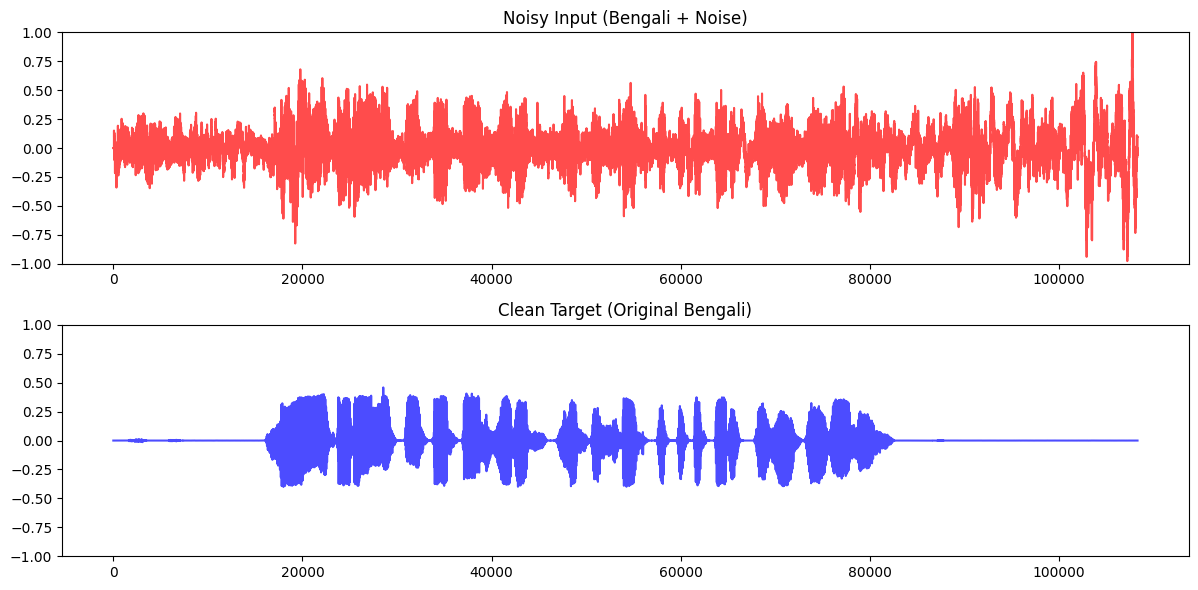

🔴 Noisy Bengali Audio (Input):


🔵 Clean Bengali Audio (Target):



### Demonstrating Noisy TIMIT Sample ###
Found TIMIT sample at index: 21575


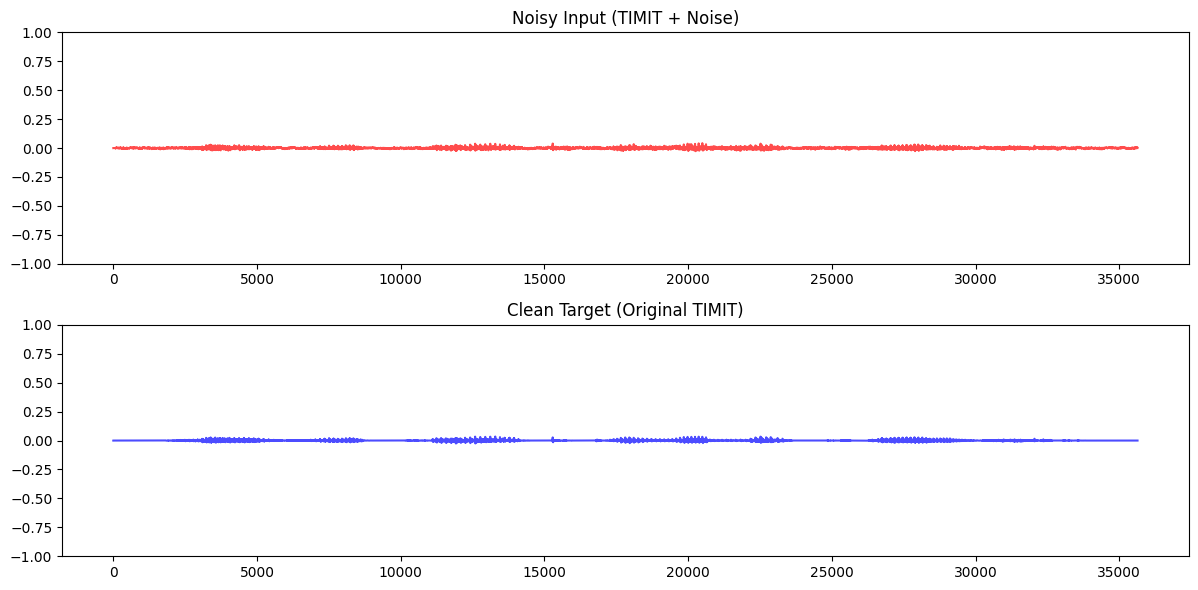

🔴 Noisy TIMIT Audio (Input):


🔵 Clean TIMIT Audio (Target):


In [ ]:
# 1. Locate Metadata
tsv_files = glob.glob(os.path.join(BENGALI_PATH, "*.tsv"))
train_tsv = [f for f in tsv_files if "train" in f][0]

# 2. Create Dataset (without limit to ensure all files are available)
full_dataset = DenoisingDataset(
    train_tsv,
    BENGALI_PATH,
    DEMAND_PATH,
    TIMIT_PATH,
    limit=None # Ensure all files are loaded
)


# --- Display Bengali Sample ---
print("### Demonstrating Noisy Bengali Sample ###")
# Find a Bengali sample index
bengali_sample_idx = -1
for i, path in enumerate(full_dataset.clean_paths):
    if BENGALI_PATH in path:
        bengali_sample_idx = i
        break

if bengali_sample_idx == -1:
    print("Could not find a Bengali sample in the dataset. Please ensure BENGALI_PATH is correct and contains files.")
else:
    print(f"Found Bengali sample at index: {bengali_sample_idx}")
    sample_bn = full_dataset[bengali_sample_idx]
    noisy_wav_bn = sample_bn['noisy_wav']
    clean_wav_bn = sample_bn['clean_wav']

    # Visualize Bengali
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.title("Noisy Input (Bengali + Noise)")
    plt.plot(noisy_wav_bn.t().numpy(), alpha=0.7, color='red')
    plt.ylim(-1, 1)

    plt.subplot(2, 1, 2)
    plt.title("Clean Target (Original Bengali)")
    plt.plot(clean_wav_bn.t().numpy(), alpha=0.7, color='blue')
    plt.ylim(-1, 1)
    plt.tight_layout()
    plt.show()

    # Listen Bengali
    print("🔴 Noisy Bengali Audio (Input):")
    ipd.display(ipd.Audio(noisy_wav_bn.numpy(), rate=SAMPLE_RATE))

    print("🔵 Clean Bengali Audio (Target):")
    ipd.display(ipd.Audio(clean_wav_bn.numpy(), rate=SAMPLE_RATE))


# --- Display TIMIT Sample ---
print("\n### Demonstrating Noisy TIMIT Sample ###")
# Find a TIMIT sample index
timit_sample_idx = -1
for i, path in enumerate(full_dataset.clean_paths):
    if TIMIT_PATH in path: # Check if the path belongs to TIMIT
        timit_sample_idx = i
        break

if timit_sample_idx == -1:
    print("Could not find a TIMIT sample in the dataset. Please ensure TIMIT_PATH is correct and contains files.")
else:
    print(f"Found TIMIT sample at index: {timit_sample_idx}")
    sample_timit = full_dataset[timit_sample_idx]
    noisy_wav_timit = sample_timit['noisy_wav']
    clean_wav_timit = sample_timit['clean_wav']

    # Visualize TIMIT
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.title("Noisy Input (TIMIT + Noise)")
    plt.plot(noisy_wav_timit.t().numpy(), alpha=0.7, color='red')
    plt.ylim(-1, 1)

    plt.subplot(2, 1, 2)
    plt.title("Clean Target (Original TIMIT)")
    plt.plot(clean_wav_timit.t().numpy(), alpha=0.7, color='blue')
    plt.ylim(-1, 1)
    plt.tight_layout()
    plt.show()

    # Listen TIMIT
    print("🔴 Noisy TIMIT Audio (Input):")
    ipd.display(ipd.Audio(noisy_wav_timit.numpy(), rate=SAMPLE_RATE))

    print("🔵 Clean TIMIT Audio (Target):")
    ipd.display(ipd.Audio(clean_wav_timit.numpy(), rate=SAMPLE_RATE))
